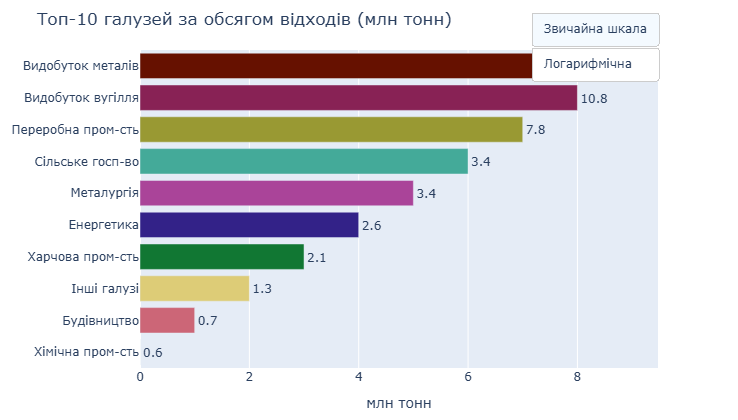

In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
 
# ── Завантаження даних ──────────────────────────────────────────
df = pd.read_csv("waste_cleaned.csv")
year_cols = ["2015","2016","2017","2018","2019","2020","2021","2022","2023","2024"]
 
def latest(row):
    """Повертає останнє ненульове значення по роках."""
    for y in reversed(year_cols):
        v = row[y]
        if pd.notna(v) and v > 0:
            return v
    return 0
 
# ── Датасети ────────────────────────────────────────────────────
 
# 1. Топ-10 галузей (КВЕД, I-IV, Україна)
df_kved = df[
    (df["region"] == "Україна") &
    (df["category"] == "За видами КВЕД") &
    (df["hazard_class"] == "I-IV. Відходи в цілому")
].copy()
df_kved["val"] = df_kved.apply(latest, axis=1)
exclude = ["Добувна промисловість і розроблення кар'єрів"]
df_kved = df_kved[~df_kved["subcategory"].isin(exclude)]
 
short_names = {
    "Добування металевих руд": "Видобуток металів",
    "Добування кам'яного та бурого вугілля": "Видобуток вугілля",
    "Переробна промисловість": "Переробна пром-сть",
    "Сільське господарство, лісове господарство та рибне господарство": "Сільське госп-во",
    "Металургійне виробництво": "Металургія",
    "Постачання електроенергії, газу, пари та кондиційованого повітря": "Енергетика",
    "Виробництво харчових продуктів": "Харчова пром-сть",
    "Інші види економічної діяльності": "Інші галузі",
    "Будівництво": "Будівництво",
    "Виробництво хімічних речовин і хімічної продукції": "Хімічна пром-сть",
}
df_kved["short"] = df_kved["subcategory"].map(short_names).fillna(df_kved["subcategory"].str[:30])
kved_top10 = df_kved.nlargest(10, "val").sort_values("val")
kved_top10["val_m"] = kved_top10["val"] / 1e6
 
# 2. Структура за матеріалами (donut)
df_mat = df[
    (df["region"] == "Україна") &
    (df["source"] == "Загалом") &
    (df["hazard_class"] == "I-IV. Відходи в цілому") &
    (~df["subcategory"].isin(["Усього"]))
].copy()
df_mat["val"] = df_mat.apply(latest, axis=1)
df_mat = df_mat[df_mat["val"] > 0].nlargest(20, "val")
short_mat = {
    "Інші мінеральні відходи (за виключенням пунктів 12.1, 12.4, 12.6, 12.7, 12.8)": "Мінеральні відходи",
    "Пуста порода від днопоглиблювальних робіт": "Пуста порода",
    "Побутові та подібні відходи": "Побутові відходи",
    "Відходи згоряння": "Відходи згоряння",
    "Тваринні екскременти, сеча та гній": "Тваринні відходи",
    "Відходи рослинного походження": "Рослинні відходи",
    "Змішані та недиференційовані матеріали": "Змішані відходи",
    "Звичайний осад": "Звичайний осад",
}
top8_mat = df_mat.head(8).copy()
other_val = df_mat.iloc[8:]["val"].sum()
top8_mat["name"] = top8_mat["subcategory"].map(short_mat).fillna(top8_mat["subcategory"].str[:22])
mat_names = list(top8_mat["name"]) + ["Інші"]
mat_vals  = list(top8_mat["val"] / 1e6) + [other_val / 1e6]
 
# 3. Динаміка галузей grouped bar (без видобутку металів)
trend_series = {
    "Переробна пром-сть":  "Переробна промисловість",
    "Металургія":          "Металургійне виробництво",
    "Видобуток вугілля":   "Добування кам'яного та бурого вугілля",
    "Сільське госп-во":    "Сільське господарство, лісове господарство та рибне господарство",
}
trend_years = ["2015","2016","2017","2018","2022","2023","2024"]
trend_data  = {}
for short, full in trend_series.items():
    row = df_kved[df_kved["subcategory"] == full]
    if not row.empty:
        vals = []
        for y in trend_years:
            v = row.iloc[0][y]
            vals.append(round(v / 1e6, 1) if pd.notna(v) and v > 0 else None)
        trend_data[short] = vals
 
# 4. Регіони топ-8
df_reg = df[
    (df["region"] != "Україна") &
    (df["category"] == "Загалом") & (df["subcategory"] == "Загалом") &
    (df["hazard_class"] == "I-IV. Відходи в цілому") &
    (df["source"].str.contains("фактичної діяльності"))
].copy()
df_reg["val"] = df_reg.apply(latest, axis=1)
reg_top8 = df_reg.nlargest(8, "val").sort_values("val")
reg_top8["val_m"] = reg_top8["val"] / 1e6
 
# 5. Частка небезпечних по регіонах (stacked 100%)
haz = df[
    (df["region"] != "Україна") &
    (df["category"] == "Загалом") & (df["subcategory"] == "Загалом") &
    (df["source"].str.contains("фактичної діяльності"))
].copy()
haz["val"] = haz.apply(latest, axis=1)
pivot = haz.groupby(["region","hazard_class"])["val"].mean().unstack(fill_value=0)
 
haz_data = []
for region in pivot.index:
    total  = pivot.loc[region, "I-IV. Відходи в цілому"]
    danger = pivot.loc[region, "I-III. Небезпечні відходи"]
    if total > 0 and region != "Луганська":
        pct_d = round(danger / total * 100, 2)
        haz_data.append({"region": region, "danger": pct_d, "safe": round(100 - pct_d, 2)})
haz_df = pd.DataFrame(haz_data).sort_values("danger", ascending=True)
 
# 6. Небезпечні по галузях
df_haz_kved = df[
    (df["region"] == "Україна") &
    (df["category"] == "За видами КВЕД") &
    (df["hazard_class"] == "I-III. Небезпечні відходи")
].copy()
df_haz_kved["val"] = df_haz_kved.apply(latest, axis=1)
df_haz_kved = df_haz_kved[df_haz_kved["val"] > 0]
total_map = dict(zip(df_kved["subcategory"], df_kved["val"]))
df_haz_kved["total"] = df_haz_kved["subcategory"].map(total_map).fillna(0)
df_haz_kved["pct"] = df_haz_kved.apply(
    lambda r: round(r["val"] / r["total"] * 100, 1) if r["total"] > 0 else None,
    axis=1
)
df_haz_kved["short"] = df_haz_kved["subcategory"].map(short_names).fillna(df_haz_kved["subcategory"].str[:30])
haz_kved_abs = df_haz_kved.sort_values("val", ascending=True)
haz_kved_pct = df_haz_kved.sort_values("pct", ascending=True)
 
# ── KPI значення ─────────────────────────────────────────────────
total_ukraine = df[
    (df["region"] == "Україна") &
    (df["source"] == "Загалом") &
    (df["hazard_class"] == "I-IV. Відходи в цілому") &
    (df["subcategory"] == "Усього")
].apply(lambda r: latest(r), axis=1).max()
 
kpi_total    = f"{round(total_ukraine/1e6)} млн т"
kpi_leader   = f"{kved_top10.iloc[-1]['short']} — {round(kved_top10.iloc[-1]['val_m'],0):.0f} млн т"
kpi_region   = f"Дніпропетровська — 114.6 млн т"
kpi_mineral  = f"{round(mat_vals[0]/sum(mat_vals)*100)}%"
 
COLORS = px.colors.qualitative.Safe
 
# ══════════════════════════════════════════════════════════════
# ГРАФІК 1 — Топ-10 галузей (з кнопками лінійна / log)
# ══════════════════════════════════════════════════════════════
fig1 = go.Figure()
fig1.add_trace(go.Bar(
    x=kved_top10["val_m"],
    y=kved_top10["short"],
    orientation="h",
    marker_color=COLORS[:10],
    text=kved_top10["val_m"].apply(lambda v: f"{v:.1f}"),
    textposition="outside",
    hovertemplate="%{y}: %{x:.1f} млн т<extra></extra>",
))
fig1.update_layout(
    title="Топ-10 галузей за обсягом відходів (млн тонн)",
    xaxis_title="млн тонн",
    height=420,
    margin=dict(l=20, r=80, t=50, b=40),
    updatemenus=[dict(
        type="buttons",
        x=1.0, y=1.12,
        buttons=[
            dict(label="Звичайна шкала",
                 method="relayout",
                 args=[{"xaxis.type": "linear", "xaxis.title.text": "млн тонн"}]),
            dict(label="Логарифмічна",
                 method="relayout",
                 args=[{"xaxis.type": "log", "xaxis.title.text": "млн тонн (log)"}]),
        ],
        bgcolor="white", bordercolor="#ccc",
    )],
)
 

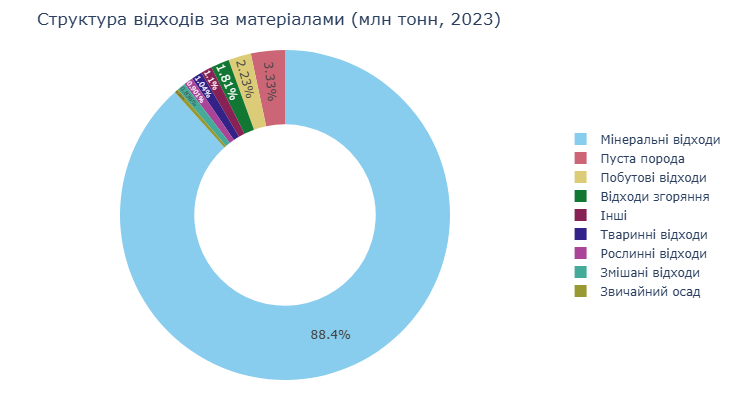

In [2]:
#ГРАФІК 2 — Структура за матеріалами (donut)
# ══════════════════════════════════════════════════════════════
fig2 = go.Figure(go.Pie(
    labels=mat_names,
    values=[round(v, 2) for v in mat_vals],
    hole=0.55,
    marker_colors=COLORS,
    hovertemplate="%{label}: %{value:.2f} млн т (%{percent})<extra></extra>",
    textinfo="percent",
    textposition="inside",
))
fig2.update_layout(
    title="Структура відходів за матеріалами (млн тонн, 2023)",
    height=420,
    legend=dict(orientation="v", x=1.02, y=0.5),
    margin=dict(l=20, r=160, t=50, b=40),
)

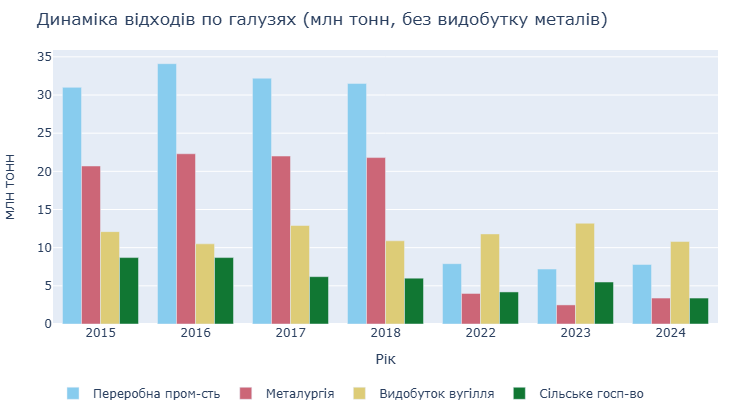

In [3]:
# ГРАФІК 3 — Динаміка галузей grouped bar
# ══════════════════════════════════════════════════════════════
fig3 = go.Figure()
for i, (name, vals) in enumerate(trend_data.items()):
    fig3.add_trace(go.Bar(
        name=name,
        x=trend_years,
        y=vals,
        marker_color=COLORS[i],
        hovertemplate=f"{name}: %{{y:.1f}} млн т<extra></extra>",
    ))
fig3.update_layout(
    title="Динаміка відходів по галузях (млн тонн, без видобутку металів)",
    barmode="group",
    xaxis_title="Рік",
    yaxis_title="млн тонн",
    height=420,
    legend=dict(orientation="h", y=-0.2),
    margin=dict(l=20, r=20, t=50, b=80),
)

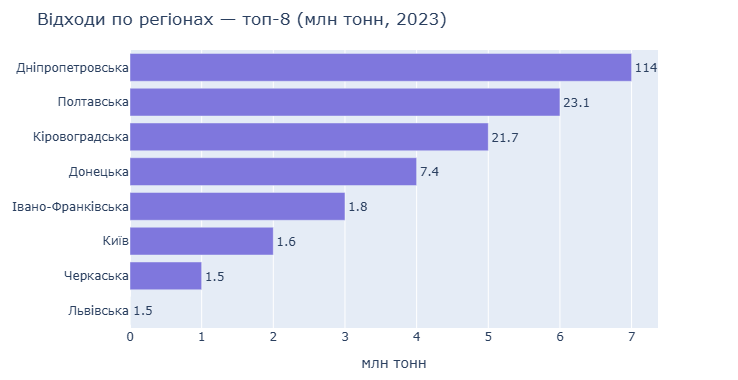

In [4]:
# ГРАФІК 4 — Регіони топ-8
# ══════════════════════════════════════════════════════════════
fig4 = go.Figure(go.Bar(
    x=reg_top8["val_m"],
    y=reg_top8["region"],
    orientation="h",
    marker_color="#7F77DD",
    text=reg_top8["val_m"].apply(lambda v: f"{v:.1f}"),
    textposition="outside",
    hovertemplate="%{y}: %{x:.1f} млн т<extra></extra>",
))
fig4.update_layout(
    title="Відходи по регіонах — топ-8 (млн тонн, 2023)",
    xaxis_title="млн тонн",
    height=380,
    margin=dict(l=20, r=80, t=50, b=40),
)

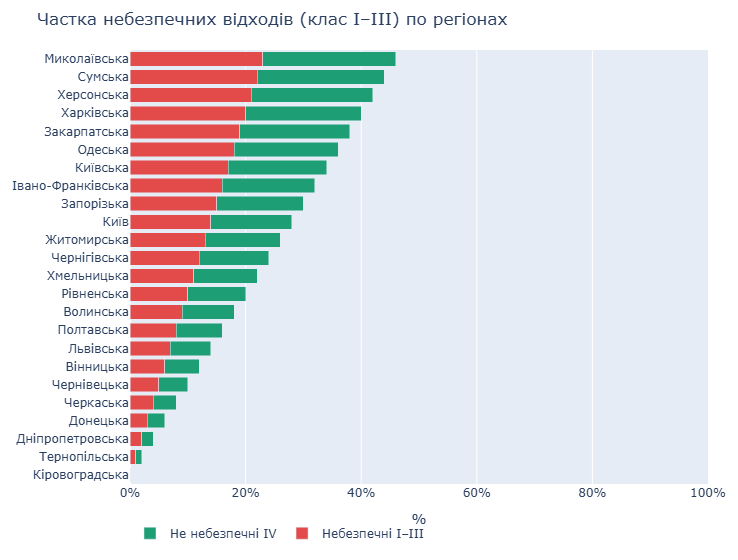

In [5]:
#ГРАФІК 5 — Частка небезпечних по регіонах stacked 100%
# ══════════════════════════════════════════════════════════════
fig5 = go.Figure()
fig5.add_trace(go.Bar(
    name="Небезпечні I–III",
    x=haz_df["danger"],
    y=haz_df["region"],
    orientation="h",
    marker_color="#E24B4A",
    hovertemplate="%{y} — небезпечні: %{x:.2f}%<extra></extra>",
))
fig5.add_trace(go.Bar(
    name="Не небезпечні IV",
    x=haz_df["safe"],
    y=haz_df["region"],
    orientation="h",
    marker_color="#1D9E75",
    hovertemplate="%{y} — не небезпечні: %{x:.2f}%<extra></extra>",
))
fig5.update_layout(
    title="Частка небезпечних відходів (клас I–III) по регіонах",
    barmode="stack",
    xaxis=dict(title="%", range=[0, 100], ticksuffix="%"),
    height=560,
    legend=dict(orientation="h", y=-0.08),
    margin=dict(l=20, r=20, t=50, b=60),
)

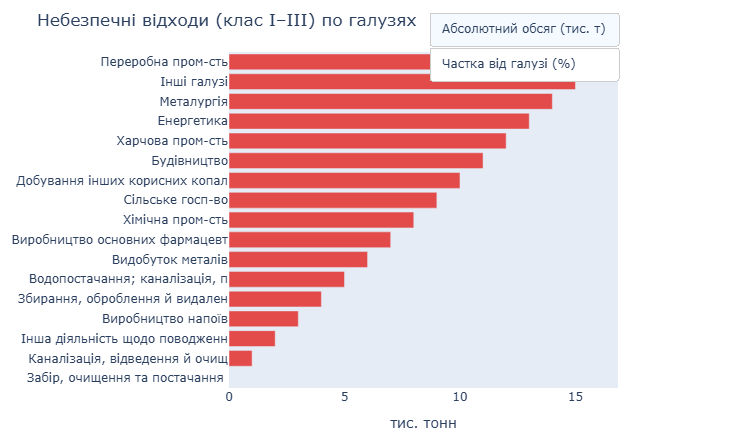

In [6]:
# ГРАФІК 6 — Небезпечні по галузях (абс / %)
# ══════════════════════════════════════════════════════════════
haz_kved_abs = df_haz_kved[
    df_haz_kved["pct"].notna() & (df_haz_kved["val"] > 0)
].sort_values("val", ascending=True)  # для тис. тонн

haz_kved_pct = df_haz_kved[
    df_haz_kved["pct"].notna() & (df_haz_kved["pct"] > 0)
].sort_values("pct", ascending=True)
fig6 = go.Figure()

# Trace 0 — абсолютний
fig6.add_trace(go.Bar(
    name="Абсолютний обсяг",
    x=haz_kved_abs["val"] / 1000,
    y=haz_kved_abs["short"],
    orientation="h",
    marker_color="#E24B4A",
    visible=True,
    hovertemplate="%{y}: %{x:.1f} тис. т<extra></extra>",
))

# Trace 1 — частка
fig6.add_trace(go.Bar(
    name="Частка від галузі",
    x=haz_kved_pct["pct"],
    y=haz_kved_pct["short"],
    orientation="h",
    marker_color="#A32D2D",
    visible=False,
    hovertemplate="%{y}: %{x:.1f}%<extra></extra>",
))
fig6.update_layout(
    title="Небезпечні відходи (клас I–III) по галузях",
    height=440,
    margin=dict(l=20, r=120, t=50, b=40),
    xaxis_title="тис. тонн",
    updatemenus=[dict(
        type="buttons",
        x=1.0, y=1.12,
        buttons=[
            dict(
                label="Абсолютний обсяг (тис. т)",
                method="update",
                args=[
                    {
                        "visible": [True, False],
                        "x": [haz_kved_abs["val"] / 1000, haz_kved_pct["pct"]],
                        "y": [haz_kved_abs["short"], haz_kved_pct["short"]],
                    },
                    {"xaxis.title.text": "тис. тонн", "xaxis.ticksuffix": ""},
                ]
            ),
            dict(
                label="Частка від галузі (%)",
                method="update",
                args=[
                    {
                        "visible": [False, True],
                        "x": [haz_kved_abs["val"] / 1000, haz_kved_pct["pct"]],
                        "y": [haz_kved_abs["short"], haz_kved_pct["short"]],
                    },
                    {"xaxis.title.text": "%", "xaxis.ticksuffix": "%"},
                ]
            ),
        ],
        bgcolor="white", bordercolor="#ccc",
    )]
)

In [7]:
from IPython.display import display, HTML

kpi_html = f"""
<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:24px;font-family:sans-serif">
  <div style="background:#f5f5f5;border-radius:10px;padding:16px">
    <div style="font-size:12px;color:#888">Всього відходів (2023)</div>
    <div style="font-size:22px;font-weight:600;margin-top:4px">{kpi_total}</div>
  </div>
  <div style="background:#f5f5f5;border-radius:10px;padding:16px">
    <div style="font-size:12px;color:#888">Лідер-галузь</div>
    <div style="font-size:16px;font-weight:600;margin-top:4px">{kpi_leader}</div>
  </div>
  <div style="background:#f5f5f5;border-radius:10px;padding:16px">
    <div style="font-size:12px;color:#888">Найбільший регіон</div>
    <div style="font-size:16px;font-weight:600;margin-top:4px">{kpi_region}</div>
  </div>
  <div style="background:#f5f5f5;border-radius:10px;padding:16px">
    <div style="font-size:12px;color:#888">Мінеральні відходи</div>
    <div style="font-size:22px;font-weight:600;margin-top:4px">{kpi_mineral} від структури</div>
  </div>
</div>
<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:8px;font-family:sans-serif">
  ... (картки без змін)
</div>
<p style="font-size:11px;color:#999;font-family:sans-serif;margin:0 0 24px">
  * Для візуалізації обрано 2023 рік — останній рік з повними даними по всіх регіонах. 
  Дані за 2024 рік доступні лише для окремих показників. 
  Дані за 2019–2021 відсутні у відкритому доступі Держстату.
</p>
"""
display(HTML(kpi_html))
 